# 📘 Notebook 4: Pretraining the LLM
## Building LLMs from Scratch Workshop

**Objective:** Pretrain our GPT model on text data using next-token prediction.

**What you'll learn:**
1. The pretraining objective (next-token prediction / cross-entropy)
2. Building a complete training loop
3. Learning rate scheduling (warmup + cosine decay)
4. Validation and perplexity measurement
5. Text generation from the trained model
6. GPU vs CPU training tips

---


## 1. Setup — Rebuild All Components

We rebuild the tokenizer, dataset, and model from previous notebooks.
In production, you'd import these. Here we include them for self-containedness.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import time
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")


Device: cpu


In [2]:
# ============================================================
# BPE Tokenizer (from Notebook 1)
# ============================================================
class BPETokenizer:
    def __init__(self, num_merges=100):
        self.num_merges = num_merges
        self.merges = {}
        self.vocab = {}
        self.inverse_vocab = {}
        self.special_tokens = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
    
    def _get_word_freqs(self, text):
        words = re.findall(r'\S+', text.lower())
        word_freqs = Counter(words)
        split_words = {}
        for word, freq in word_freqs.items():
            split_words[tuple(list(word) + ['</w>'])] = freq
        return split_words
    
    def _get_pair_counts(self, word_freqs):
        pairs = Counter()
        for word_tokens, freq in word_freqs.items():
            for i in range(len(word_tokens) - 1):
                pairs[(word_tokens[i], word_tokens[i + 1])] += freq
        return pairs
    
    def _merge_pair(self, word_freqs, pair):
        merged = pair[0] + pair[1]
        new_wf = {}
        for word_tokens, freq in word_freqs.items():
            new_tokens = []
            i = 0
            while i < len(word_tokens):
                if i < len(word_tokens) - 1 and word_tokens[i] == pair[0] and word_tokens[i+1] == pair[1]:
                    new_tokens.append(merged)
                    i += 2
                else:
                    new_tokens.append(word_tokens[i])
                    i += 1
            new_wf[tuple(new_tokens)] = freq
        return new_wf
    
    def train(self, text):
        word_freqs = self._get_word_freqs(text)
        initial_chars = set()
        for wt in word_freqs.keys():
            for t in wt:
                initial_chars.add(t)
        
        for i in range(self.num_merges):
            pairs = self._get_pair_counts(word_freqs)
            if not pairs:
                break
            best_pair, count = pairs.most_common(1)[0]
            if count < 2:
                break
            self.merges[best_pair] = best_pair[0] + best_pair[1]
            word_freqs = self._merge_pair(word_freqs, best_pair)
        
        self.vocab = dict(self.special_tokens)
        idx = len(self.special_tokens)
        for ch in sorted(initial_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1
        for pair, merged in self.merges.items():
            if merged not in self.vocab:
                self.vocab[merged] = idx
                idx += 1
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        print(f"BPE trained: vocab_size={len(self.vocab)}, merges={len(self.merges)}")
    
    def _tokenize_word(self, word):
        tokens = list(word) + ['</w>']
        for pair, merged in self.merges.items():
            i = 0
            while i < len(tokens) - 1:
                if tokens[i] == pair[0] and tokens[i+1] == pair[1]:
                    tokens = tokens[:i] + [merged] + tokens[i+2:]
                else:
                    i += 1
        return tokens
    
    def encode(self, text):
        words = re.findall(r'\S+', text.lower())
        ids = []
        for word in words:
            for token in self._tokenize_word(word):
                ids.append(self.vocab.get(token, self.vocab['<UNK>']))
        return ids
    
    def decode(self, ids):
        tokens = [self.inverse_vocab.get(i, '<UNK>') for i in ids]
        return ''.join(tokens).replace('</w>', ' ').strip()
    
    @property
    def vocab_size(self):
        return len(self.vocab)


In [3]:
# ============================================================
# Dataset (from Notebook 1)
# ============================================================
class LLMDataset(Dataset):
    def __init__(self, token_ids, context_length=64, stride=1):
        self.input_ids = []
        self.target_ids = []
        for i in range(0, len(token_ids) - context_length, stride):
            self.input_ids.append(torch.tensor(token_ids[i:i+context_length], dtype=torch.long))
            self.target_ids.append(torch.tensor(token_ids[i+1:i+context_length+1], dtype=torch.long))
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


In [4]:
# ============================================================
# GPT Model (from Notebook 3)
# ============================================================
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(emb_dim))
        self.beta = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        var = x.var(-1, keepdim=True, unbiased=False)
        return self.gamma * (x - mean) / torch.sqrt(var + self.eps) + self.beta

class CausalMultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        emb_dim = config['emb_dim']
        self.num_heads = config['num_heads']
        self.head_dim = emb_dim // self.num_heads
        self.qkv_proj = nn.Linear(emb_dim, 3 * emb_dim, bias=False)
        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=False)
        self.attn_dropout = nn.Dropout(config['drop_rate'])
        self.resid_dropout = nn.Dropout(config['drop_rate'])
        mask = torch.triu(torch.ones(config['context_length'], config['context_length']), diagonal=1)
        self.register_buffer('mask', mask.bool())
    
    def forward(self, x):
        B, T, C = x.shape
        Q, K, V = self.qkv_proj(x).chunk(3, dim=-1)
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        attn = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)
        attn.masked_fill_(self.mask[:T, :T].unsqueeze(0).unsqueeze(0), float('-inf'))
        attn = self.attn_dropout(F.softmax(attn, dim=-1))
        out = attn @ V
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(out))

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(config['emb_dim'], config['emb_dim'] * config.get('ff_mult', 4)),
            nn.GELU(),
            nn.Linear(config['emb_dim'] * config.get('ff_mult', 4), config['emb_dim']),
            nn.Dropout(config['drop_rate'])
        )
    def forward(self, x):
        return self.layers(x)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config['emb_dim'])
        self.attn = CausalMultiHeadAttention(config)
        self.ln2 = LayerNorm(config['emb_dim'])
        self.ffn = FeedForward(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config['vocab_size'], config['emb_dim'])
        self.pos_emb = nn.Embedding(config['context_length'], config['emb_dim'])
        self.drop = nn.Dropout(config['drop_rate'])
        self.blocks = nn.Sequential(*[TransformerBlock(config) for _ in range(config['num_layers'])])
        self.final_ln = LayerNorm(config['emb_dim'])
        self.lm_head = nn.Linear(config['emb_dim'], config['vocab_size'], bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)
    
    def forward(self, token_ids, targets=None):
        B, T = token_ids.shape
        tok_emb = self.tok_emb(token_ids)
        pos_emb = self.pos_emb(torch.arange(T, device=token_ids.device))
        x = self.drop(tok_emb + pos_emb)
        x = self.blocks(x)
        x = self.final_ln(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

print("All components loaded!")


All components loaded!


## 2. Prepare Training Data

In [5]:
# Extended corpus for better pretraining
CORPUS = """The quick brown fox jumps over the lazy dog.
Machine learning is a subset of artificial intelligence.
Neural networks learn representations from data automatically.
Transformers revolutionized natural language processing in 2017.
Attention is all you need was the groundbreaking paper by Google.
Large language models can generate human-like text fluently.
GPT stands for Generative Pre-trained Transformer architecture.
Training a language model requires massive amounts of text data.
Tokenization converts raw text into numerical sequences for models.
The embedding layer maps token IDs to dense vector representations.
Self-attention allows each token to attend to all other tokens.
Multi-head attention runs multiple attention operations in parallel.
The transformer block combines attention with feed-forward networks.
Pre-training teaches the model general language understanding.
Fine-tuning adapts the pre-trained model to specific tasks.
Supervised fine-tuning uses labeled instruction-response pairs.
RLHF uses human preferences to align model outputs with values.
A reward model scores responses based on human preference data.
PPO is a policy optimization algorithm used in RLHF training.
The KL divergence penalty prevents the model from diverging too far.
Temperature controls the randomness of text generation output.
Top-k sampling limits generation to the k most likely next tokens.
Perplexity measures how well a language model predicts text.
Cross-entropy loss is the standard training objective for LLMs.
Batch size and learning rate are critical hyperparameters to tune.
Gradient clipping prevents exploding gradients during training.
Layer normalization stabilizes training of deep neural networks.
Residual connections help gradients flow through deep architectures.
The vocabulary size determines the number of unique tokens.
Byte-pair encoding is a subword tokenization algorithm.
The special tokens include padding beginning and end of sequence.
Positional encoding tells the model about token order in sequence.
Causal masking ensures the model only looks at previous tokens.
The softmax function converts logits into probability distributions.
Greedy decoding always picks the most probable next token.
Beam search explores multiple generation paths simultaneously.
The context window limits how many tokens the model can process.
Scaling laws predict model performance based on size and data.
Emergent abilities appear in sufficiently large language models.
Transfer learning leverages knowledge from pre-training tasks.
Deep learning has transformed computer vision and natural language processing.
Convolutional neural networks are effective for image recognition tasks.
Recurrent neural networks process sequential data like text and time series.
The attention mechanism was first used in sequence to sequence models.
Encoder decoder architectures are used for translation and summarization.
Decoder only models like GPT are used for text generation tasks.
The training data quality significantly impacts model performance.
Data augmentation techniques can improve model robustness and generalization.
Regularization methods like dropout prevent overfitting during training.
The Adam optimizer adapts learning rates for each parameter individually.
Learning rate warmup helps stabilize training in the early stages.
Cosine annealing gradually reduces the learning rate during training.
Mixed precision training uses float16 to speed up computation.
Gradient accumulation enables larger effective batch sizes on limited memory.
Model checkpointing saves progress during long training runs.
The validation set is used to monitor overfitting during training.
Early stopping halts training when validation loss stops improving.
The test set is used only for final evaluation of model performance.
Hyperparameter tuning is essential for optimal model performance.
Grid search and random search are basic hyperparameter optimization methods.
"""

# Repeat corpus to get more training data
CORPUS = CORPUS * 5  # ~5x more data for better training

# Train tokenizer
tokenizer = BPETokenizer(num_merges=200)
tokenizer.train(CORPUS)

# Tokenize
all_ids = tokenizer.encode(CORPUS)
print(f"\nTotal tokens: {len(all_ids)}")

# Split into train/val (90/10)
split = int(0.9 * len(all_ids))
train_ids = all_ids[:split]
val_ids = all_ids[split:]
print(f"Train tokens: {len(train_ids)}")
print(f"Val tokens:   {len(val_ids)}")


BPE trained: vocab_size=238, merges=200

Total tokens: 7660
Train tokens: 6894
Val tokens:   766


In [6]:
# Create DataLoaders
CONTEXT_LENGTH = 64
BATCH_SIZE = 8
STRIDE = 4

train_dataset = LLMDataset(train_ids, context_length=CONTEXT_LENGTH, stride=STRIDE)
val_dataset = LLMDataset(val_ids, context_length=CONTEXT_LENGTH, stride=STRIDE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")


Train batches: 213
Val batches:   22


## 3. Training Infrastructure

### 3.1 Learning Rate Schedule
We use **warmup + cosine decay**, the standard for LLM training:
- First N steps: linearly increase LR from 0 to max_lr (warmup)
- Remaining steps: cosine decay from max_lr to min_lr


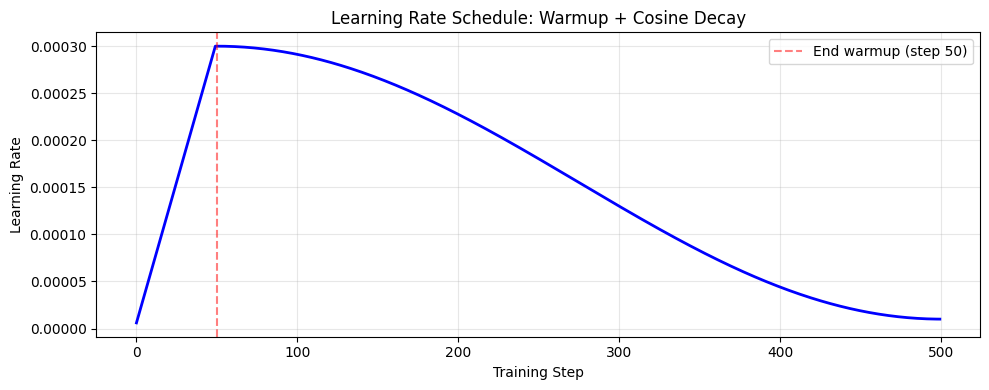

In [8]:
def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    """
    Compute learning rate with warmup + cosine decay.
    
    Args:
        step: Current training step
        warmup_steps: Number of warmup steps
        max_steps: Total training steps
        max_lr: Maximum (peak) learning rate
        min_lr: Minimum learning rate
    
    Returns:
        Learning rate for this step
    """
    # Warmup phase
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    
    # Cosine decay phase
    if step >= max_steps:
        return min_lr
    
    # Cosine decay
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

# Visualize the schedule
max_steps = 500
warmup_steps = 50
max_lr = 3e-4
min_lr = 1e-5

steps = list(range(max_steps))
lrs = [get_lr(s, warmup_steps, max_steps, max_lr, min_lr) for s in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps, lrs, 'b-', linewidth=2)
plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.5, label=f'End warmup (step {warmup_steps})')
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule: Warmup + Cosine Decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\lr_schedule.png', dpi=100)
plt.show()


### 3.2 Evaluation Function

In [9]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    """Compute average loss and perplexity on a dataset."""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    for input_ids, target_ids in data_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        
        _, loss = model(input_ids, target_ids)
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / max(num_batches, 1)
    perplexity = math.exp(avg_loss) if avg_loss < 20 else float('inf')
    
    return avg_loss, perplexity


### 3.3 Text Generation Helper

In [10]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=50, temperature=0.8, top_k=20, device='cpu'):
    """Generate text from a prompt."""
    model.eval()
    token_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    context_length = model.config['context_length']
    
    for _ in range(max_new_tokens):
        idx_cond = token_ids[:, -context_length:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-8)
        
        if top_k is not None:
            topk_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < topk_vals[:, -1:]] = float('-inf')
        
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1) if temperature > 0 else torch.argmax(probs, dim=-1, keepdim=True)
        token_ids = torch.cat([token_ids, next_token], dim=1)
    
    return tokenizer.decode(token_ids[0].tolist())


## 4. The Pretraining Loop

This is where the magic happens! We train the model to predict the next token.

**Key components:**
- AdamW optimizer (Adam with weight decay)
- Learning rate warmup + cosine decay
- Gradient clipping
- Periodic evaluation and text generation samples


In [11]:
# ============================================================
# Initialize Model
# ============================================================
GPT_CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 128,
    "num_heads": 4,
    "num_layers": 4,
    "drop_rate": 0.1,
    "ff_mult": 4,
}

model = GPTModel(GPT_CONFIG).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Config: {GPT_CONFIG}")


Model parameters: 829,952
Config: {'vocab_size': 238, 'context_length': 64, 'emb_dim': 128, 'num_heads': 4, 'num_layers': 4, 'drop_rate': 0.1, 'ff_mult': 4}


In [12]:
# ============================================================
# Training Configuration
# ============================================================
NUM_EPOCHS = 15
MAX_LR = 3e-4
MIN_LR = 1e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
WARMUP_RATIO = 0.1
EVAL_EVERY = 50  # Evaluate every N steps
GENERATE_EVERY = 100  # Generate sample every N steps

# Calculate total steps
total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = int(WARMUP_RATIO * total_steps)
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=MAX_LR, 
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)  # GPT-2 style
)


Total training steps: 3195
Warmup steps: 319


In [13]:
# ============================================================
# TRAINING LOOP
# ============================================================
print("=" * 60)
print("STARTING PRETRAINING")
print("=" * 60)

train_losses = []
val_losses = []
val_perplexities = []
learning_rates = []
step = 0
best_val_loss = float('inf')

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_steps = 0
    
    for batch_idx, (input_ids, target_ids) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        
        # Update learning rate
        lr = get_lr(step, warmup_steps, total_steps, MAX_LR, MIN_LR)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        learning_rates.append(lr)
        
        # Forward pass
        logits, loss = model(input_ids, target_ids)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        # Update weights
        optimizer.step()
        
        train_losses.append(loss.item())
        epoch_loss += loss.item()
        epoch_steps += 1
        step += 1
        
        # Periodic evaluation
        if step % EVAL_EVERY == 0:
            val_loss, val_ppl = evaluate(model, val_loader, device)
            val_losses.append((step, val_loss))
            val_perplexities.append((step, val_ppl))
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'config': GPT_CONFIG,
                    'step': step,
                    'val_loss': val_loss
                }, 'gpt_pretrained_best.pt')
            
            elapsed = time.time() - start_time
            print(f"  Step {step:4d} | Train Loss: {loss.item():.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.1f} | "
                  f"LR: {lr:.2e} | Time: {elapsed:.0f}s")
            
            model.train()
        
        # Periodic text generation
        if step % GENERATE_EVERY == 0:
            sample = generate(model, tokenizer, "the transformer", 
                            max_new_tokens=30, temperature=0.8, device=device)
            print(f"  Sample: '{sample[:100]}...'")
    
    avg_epoch_loss = epoch_loss / epoch_steps
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} — Avg Train Loss: {avg_epoch_loss:.4f}")

total_time = time.time() - start_time
print(f"\nTraining complete! Total time: {total_time:.1f}s")
print(f"Best validation loss: {best_val_loss:.4f}")


STARTING PRETRAINING
  Step   50 | Train Loss: 5.3054 | Val Loss: 5.2998 | Val PPL: 200.3 | LR: 4.70e-05 | Time: 3s
  Step  100 | Train Loss: 5.0211 | Val Loss: 5.0373 | Val PPL: 154.1 | LR: 9.40e-05 | Time: 6s
  Sample: 'the transformer cms ls. ls iibbs the sariddffinbbre ly training  fs...'
  Step  150 | Train Loss: 4.6154 | Val Loss: 4.6876 | Val PPL: 108.6 | LR: 1.41e-04 | Time: 8s
  Step  200 | Train Loss: 4.4056 | Val Loss: 4.3312 | Val PPL: 76.0 | LR: 1.88e-04 | Time: 11s
  Sample: 'the transformer to the slfinteler bathe spectiner bnaifrolle and lithe...'

Epoch 1/15 — Avg Train Loss: 4.9510
  Step  250 | Train Loss: 4.0566 | Val Loss: 3.9867 | Val PPL: 53.9 | LR: 2.35e-04 | Time: 14s
  Step  300 | Train Loss: 3.7502 | Val Loss: 3.6295 | Val PPL: 37.7 | LR: 2.82e-04 | Time: 17s
  Sample: 'the transformer be . the model orddictmabatch model performance. pts rate humreada. mder...'
  Step  350 | Train Loss: 2.9277 | Val Loss: 3.2430 | Val PPL: 25.6 | LR: 3.00e-04 | Time: 19s
  St

## 5. Training Curves & Analysis

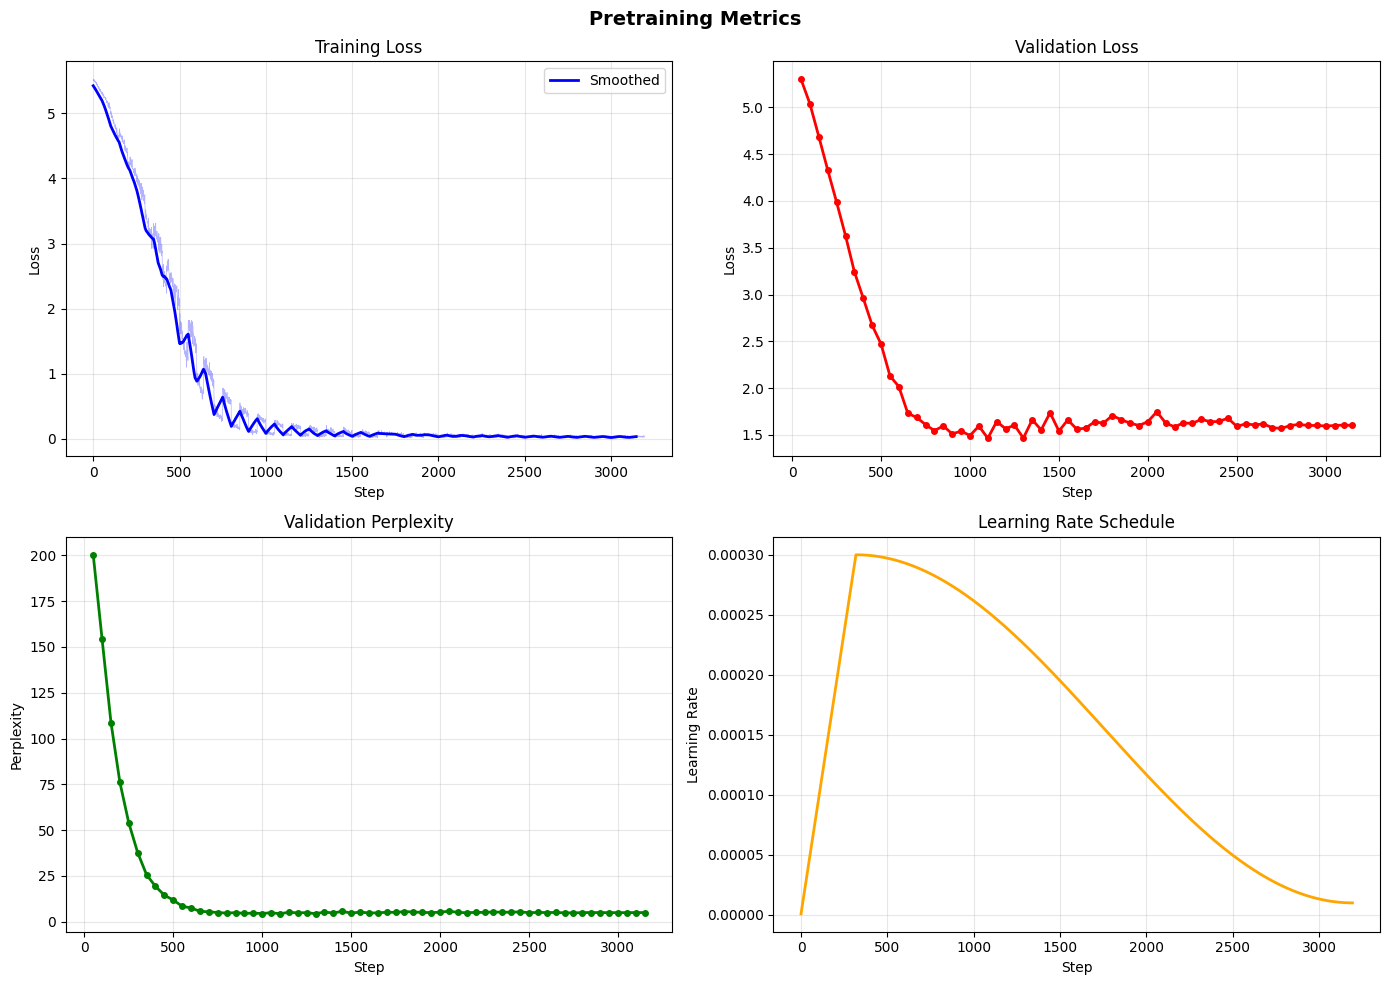

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training loss
axes[0, 0].plot(train_losses, alpha=0.3, color='blue', linewidth=0.5)
# Smoothed
window = min(50, len(train_losses) // 5)
if window > 1:
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(smoothed, color='blue', linewidth=2, label='Smoothed')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation loss
if val_losses:
    val_steps, val_loss_vals = zip(*val_losses)
    axes[0, 1].plot(val_steps, val_loss_vals, 'ro-', linewidth=2, markersize=4)
    axes[0, 1].set_xlabel('Step')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Perplexity
if val_perplexities:
    ppl_steps, ppl_vals = zip(*val_perplexities)
    axes[1, 0].plot(ppl_steps, ppl_vals, 'go-', linewidth=2, markersize=4)
    axes[1, 0].set_xlabel('Step')
    axes[1, 0].set_ylabel('Perplexity')
    axes[1, 0].set_title('Validation Perplexity')
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learning rate
axes[1, 1].plot(learning_rates, color='orange', linewidth=2)
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Pretraining Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\results\\pretraining_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Text Generation from Pretrained Model

In [15]:
# Load best checkpoint
checkpoint = torch.load(r'D:\\Documents\\Unisole\\UniTransformerWorkshop\\models\\gpt_pretrained_best.pt', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model (val_loss={checkpoint['val_loss']:.4f})")

# Generate with different settings
prompts = [
    "the transformer",
    "machine learning",
    "attention is",
    "neural networks",
    "training a language model",
]

print("\n" + "=" * 60)
print("TEXT GENERATION SAMPLES")
print("=" * 60)

for prompt in prompts:
    print(f"\n--- Prompt: '{prompt}' ---")
    
    # Greedy
    out = generate(model, tokenizer, prompt, max_new_tokens=40, temperature=0.0, device=device)
    print(f"  Greedy (T=0.0):  {out[:120]}")
    
    # Low temperature
    out = generate(model, tokenizer, prompt, max_new_tokens=40, temperature=0.5, top_k=10, device=device)
    print(f"  Focused (T=0.5): {out[:120]}")
    
    # High temperature
    out = generate(model, tokenizer, prompt, max_new_tokens=40, temperature=1.2, top_k=30, device=device)
    print(f"  Creative (T=1.2):{out[:120]}")


Loaded best model (val_loss=1.4650)

TEXT GENERATION SAMPLES

--- Prompt: 'the transformer' ---
  Greedy (T=0.0):  the transformer block combines attention with feed-forward networks. pre-training teaches the model general language und
  Focused (T=0.5): the transformer block combines attention with feed-forward networks. pre-training teaches the model general language und
  Creative (T=1.2):the transformer block combines attention with feed-forward networks. pre-training teaches the model general language und

--- Prompt: 'machine learning' ---
  Greedy (T=0.0):  machine learning rates to spes. rundic to attend to all other tokens. multi-head attention runs multiple attention opera
  Focused (T=0.5): machine learning ratelligence. neural networks learn representations from data automatically. transformers revolutionize
  Creative (T=1.2):machine learning rate are criized model ith the tasks. sures hf urent a sures respecific tasks. superparameterxtorithm.

--- Prompt: 'attention is' -

## 7. Save Pretrained Model for SFT (Notebook 5)

In [16]:
# Save the final pretrained model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': GPT_CONFIG,
    'tokenizer_vocab': tokenizer.vocab,
    'tokenizer_merges': {f"{k[0]}|||{k[1]}": v for k, v in tokenizer.merges.items()},
    'tokenizer_special_tokens': tokenizer.special_tokens,
    'tokenizer_num_merges': tokenizer.num_merges,
}, 'gpt_pretrained_final.pt')
print("Pretrained model saved to gpt_pretrained_final.pt")
print("Ready for Supervised Fine-Tuning in Notebook 5!")


Pretrained model saved to gpt_pretrained_final.pt
Ready for Supervised Fine-Tuning in Notebook 5!


## 8. Exercises & Summary

### Exercise 1: Hyperparameter Exploration
Try different combinations: `emb_dim` (64, 128, 256), `num_layers` (2, 4, 6), `num_heads` (2, 4, 8).
Plot validation loss curves for each configuration.

### Exercise 2: Longer Training
Train for 50+ epochs. Does the model overfit? How can you tell?

### Exercise 3: Data Scaling
Double/triple the corpus size. How does it affect perplexity?

---

## 🎯 Interview Questions

1. **Why cross-entropy loss for language modeling?** — We want the model to maximize the probability of the correct next token, which is equivalent to minimizing cross-entropy between the predicted distribution and the one-hot target.

2. **What is perplexity?** — Perplexity = exp(loss). It represents how many tokens the model is "choosing between" on average. Lower is better. PPL=1 means perfect prediction.

3. **Why warmup?** — Early in training, the model hasn't learned good representations yet. Large learning rates can cause divergence. Warmup starts small and gradually increases.

4. **Why gradient clipping?** — Prevents exploding gradients that can destabilize training. Common threshold is 1.0.

---

## ✅ Summary

1. ✅ Trained GPT model using next-token prediction
2. ✅ Implemented warmup + cosine decay LR schedule
3. ✅ Computed validation loss and perplexity
4. ✅ Generated text with temperature and top-k sampling
5. ✅ Saved pretrained model for fine-tuning

**Next: Notebook 5 — Supervised Fine-Tuning (SFT) →**
